In [4]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from surprise import Reader, Dataset, SVD
from surprise.model_selection import cross_validate

# DATASET

In [ ]:
print("=== TAHAP 1: PERSIAPAN & PEMBERSIHAN DATA ===")

# 1. Load Data Utama
tourism_id = pd.read_csv('datasets/tourism_with_id.csv')
rating = pd.read_csv('datasets/tourism_rating.csv')
user = pd.read_csv('datasets/user.csv')

# 2. Membersihkan Kolom Sampah
# Menghapus kolom Unnamed yang kosong di ujung kanan tabel
tourism_id = tourism_id.drop(['Unnamed: 11', 'Unnamed: 12'], axis=1, errors='ignore')

# 3. Menangani Nilai Kosong (Missing Values) pada Durasi
# Ini sangat penting karena nanti kamu butuh 'Time_Minutes' untuk menghitung durasi itinerary.
# Kita isi nilai yang kosong dengan median (nilai tengah).
median_waktu = tourism_id['Time_Minutes'].median()
tourism_id['Time_Minutes'] = tourism_id['Time_Minutes'].fillna(median_waktu)

# 4. Feature Engineering: Menciptakan Kolom 'Mood'
# Kita memetakan 'Mood' berdasarkan kolom 'Category' yang sudah ada.
def tentukan_mood(kategori):
    if kategori == 'Bahari':
        return 'Santai, Alam'
    elif kategori == 'Budaya':
        return 'Edukasi, Tenang'
    elif kategori == 'Taman Hiburan':
        return 'Seru, Keluarga'
    elif kategori == 'Cagar Alam':
        return 'Petualangan, Alam'
    elif kategori == 'Pusat Perbelanjaan':
        return 'Santai, Belanja'
    elif kategori == 'Tempat Ibadah':
        return 'Tenang, Religi'
    else:
        return 'Umum'

tourism_id['Mood'] = tourism_id['Category'].apply(tentukan_mood)

# 5. Feature Engineering: Menciptakan "Tags" untuk Content-Based Filtering
# Kita gabungkan semua atribut teks menjadi satu kolom 'Tags' agar algoritma TF-IDF nanti bisa membacanya dengan mudah.
tourism_id['Tags'] = tourism_id['Category'] + " " + tourism_id['City'] + " " + tourism_id['Mood']

print("\nDataset Pariwisata siap digunakan!")
print("Sampel data dengan penambahan kolom Mood dan Tags:")
display(tourism_id[['Place_Name', 'Category', 'Price', 'Time_Minutes', 'Mood', 'Tags']].head())

=== TAHAP 1: PERSIAPAN & PEMBERSIHAN DATA ===

Dataset Pariwisata siap digunakan!
Sampel data dengan penambahan kolom Mood dan Tags:


,Place_Name,Category,Price,Time_Minutes,Mood,Tags
0,Monumen Nasional,Budaya,20000,15.0,"Edukasi, Tenang","Budaya Jakarta Edukasi, Tenang"
1,Kota Tua,Budaya,0,90.0,"Edukasi, Tenang","Budaya Jakarta Edukasi, Tenang"
2,Dunia Fantasi,Taman Hiburan,270000,360.0,"Seru, Keluarga","Taman Hiburan Jakarta Seru, Keluarga"
3,Taman Mini Indonesia Indah (TMII),Taman Hiburan,10000,60.0,"Seru, Keluarga","Taman Hiburan Jakarta Seru, Keluarga"
4,Atlantis Water Adventure,Taman Hiburan,94000,60.0,"Seru, Keluarga","Taman Hiburan Jakarta Seru, Keluarga"


# Modeling

In [6]:
print("=== TAHAP 2: MEMBANGUN ENGINE REKOMENDASI ===")

# ---------------------------------------------------------
# A. Engine Content-Based (TF-IDF) untuk "Wisata Mirip"
# ---------------------------------------------------------
# Mengubah teks pada kolom 'Tags' menjadi matriks angka
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(tourism_id['Tags'])

# Menghitung derajat kemiripan antar tempat wisata
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

def get_similar_places(place_name, k=5):
    try:
        idx = tourism_id[tourism_id['Place_Name'].str.lower() == place_name.lower()].index[0]
        sim_scores = list(enumerate(cosine_sim[idx]))
        sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
        top_indices = [i[0] for i in sim_scores[1:k+1]]
        return tourism_id.iloc[top_indices][['Place_Name', 'Category', 'City', 'Mood', 'Price', 'Rating']]
    except IndexError:
        return "Tempat tidak ditemukan."

# ---------------------------------------------------------
# B. Engine Knowledge-Based untuk "Rekomendasi Utama User"
# ---------------------------------------------------------
def get_user_recommendation(kota, mood, budget_total, pax, waktu_menit):
    # 1. Filter Lokasi
    df_filtered = tourism_id[tourism_id['City'].str.lower() == kota.lower()].copy()
    
    # 2. Filter Mood (Mencari teks yang mengandung mood inputan)
    if mood:
        df_filtered = df_filtered[df_filtered['Mood'].str.contains(mood, case=False, na=False)]
        
    # 3. Kalkulasi Biaya Total (Harga Tiket x Jumlah Orang)
    df_filtered['Total_Biaya'] = df_filtered['Price'] * pax
    
    # 4. Filter Budget dan Durasi Maksimal
    df_filtered = df_filtered[(df_filtered['Total_Biaya'] <= budget_total) & 
                              (df_filtered['Time_Minutes'] <= waktu_menit)]
    
    # 5. Urutkan dari Rating tertinggi (Rekomendasi terbaik di atas)
    df_filtered = df_filtered.sort_values(by='Rating', ascending=False)
    
    # Jika tidak ada yang cocok
    if df_filtered.empty:
        return "Maaf, tidak ada wisata yang sesuai dengan kriteria budget/waktu Anda."
        
    return df_filtered[['Place_Name', 'Category', 'Mood', 'Time_Minutes', 'Total_Biaya', 'Rating']].head(5)

# --- MARI KITA UJI COBA ---
print("\n[TEST 1] Fitur Rekomendasi Utama (Berdasarkan Input Website)")
print("Skenario: User ingin ke Jakarta, Mood Santai, Budget Rp 100.000 untuk 2 orang, Max waktu 3 jam (180 menit)")
hasil_utama = get_user_recommendation(kota='Jakarta', mood='Santai', budget_total=100000, pax=2, waktu_menit=180)
display(hasil_utama)

print("\n[TEST 2] Fitur Wisata Mirip (Jika user tertarik dengan salah satu tempat)")
print("Skenario: Menampilkan tempat yang mirip dengan 'Taman Suropati'")
hasil_mirip = get_similar_places('Taman Suropati', k=3)
display(hasil_mirip)

=== TAHAP 2: MEMBANGUN ENGINE REKOMENDASI ===

[TEST 1] Fitur Rekomendasi Utama (Berdasarkan Input Website)
Skenario: User ingin ke Jakarta, Mood Santai, Budget Rp 100.000 untuk 2 orang, Max waktu 3 jam (180 menit)


,Place_Name,Category,Mood,Time_Minutes,Total_Biaya,Rating
28,Wisata Kuliner Pecenongan,Pusat Perbelanjaan,"Santai, Belanja",60.0,0,5.0
34,Grand Indonesia Mall,Pusat Perbelanjaan,"Santai, Belanja",120.0,0,4.7
79,Plaza Indonesia,Pusat Perbelanjaan,"Santai, Belanja",120.0,0,4.7
10,Pulau Bidadari,Bahari,"Santai, Alam",60.0,10000,4.6
83,Kawasan Kuliner BSM,Pusat Perbelanjaan,"Santai, Belanja",60.0,0,4.6



[TEST 2] Fitur Wisata Mirip (Jika user tertarik dengan salah satu tempat)
Skenario: Menampilkan tempat yang mirip dengan 'Taman Suropati'


,Place_Name,Category,City,Mood,Price,Rating
3,Taman Mini Indonesia Indah (TMII),Taman Hiburan,Jakarta,"Seru, Keluarga",10000,4.5
4,Atlantis Water Adventure,Taman Hiburan,Jakarta,"Seru, Keluarga",94000,4.5
5,Taman Impian Jaya Ancol,Taman Hiburan,Jakarta,"Seru, Keluarga",25000,4.5


In [7]:
print("=== TAHAP 3 (REVISI): MEMBANGUN ENGINE WISATA POPULER UNTUK LANDING PAGE ===")

# 1. Menghitung Jumlah Ulasan tiap tempat dari tabel rating
jumlah_review = rating.groupby('Place_Id').size().reset_index(name='Jumlah_Ulasan')

# 2. Gabungkan ke tabel utama tourism_id
tourism_id = pd.merge(tourism_id, jumlah_review, on='Place_Id', how='left')
tourism_id['Jumlah_Ulasan'] = tourism_id['Jumlah_Ulasan'].fillna(0)

# 3. Menerapkan Algoritma Weighted Rating (WR)
# v = Jumlah Ulasan
v = tourism_id['Jumlah_Ulasan']
# R = Rata-rata Rating tempat tersebut
R = tourism_id['Rating']
# C = Rata-rata Rating SELURUH tempat wisata
C = tourism_id['Rating'].mean()
# m = Batas minimum ulasan agar masuk perhitungan (kita ambil persentil ke-75)
m = tourism_id['Jumlah_Ulasan'].quantile(0.75)

# Terapkan Rumus
tourism_id['Skor_Popularitas'] = ((v / (v + m)) * R) + ((m / (v + m)) * C)

def get_popular_destinations(kota=None, top_n=5):
    df_pop = tourism_id.copy()
    
    # Jika user ingin melihat wisata populer per kota
    if kota:
        df_pop = df_pop[df_pop['City'].str.lower() == kota.lower()]
        
    # Urutkan dari Skor Popularitas tertinggi
    df_pop = df_pop.sort_values(by='Skor_Popularitas', ascending=False)
    
    return df_pop[['Place_Name', 'Category', 'City', 'Rating', 'Jumlah_Ulasan', 'Skor_Popularitas']].head(top_n)

# --- MARI KITA UJI COBA ---
print("\n[TEST 3A] Menampilkan 5 Wisata Paling Populer se-Indonesia (Untuk Landing Page)")
display(get_popular_destinations(top_n=5))

print("\n[TEST 3B] Menampilkan 5 Wisata Paling Populer khusus di Yogyakarta")
display(get_popular_destinations(kota='Yogyakarta', top_n=5))

=== TAHAP 3 (REVISI): MEMBANGUN ENGINE WISATA POPULER UNTUK LANDING PAGE ===

[TEST 3A] Menampilkan 5 Wisata Paling Populer se-Indonesia (Untuk Landing Page)


,Place_Name,Category,City,Rating,Jumlah_Ulasan,Skor_Popularitas
28,Wisata Kuliner Pecenongan,Pusat Perbelanjaan,Jakarta,5.0,33,4.754451
94,Desa Wisata Sungai Code Jogja Kota,Taman Hiburan,Yogyakarta,5.0,25,4.715933
68,Freedom Library,Budaya,Jakarta,5.0,25,4.715933
322,Kebun Tanaman Obat Sari Alam,Cagar Alam,Bandung,4.9,31,4.691449
279,Gereja Tiberias Indonesia Bandung,Tempat Ibadah,Bandung,4.9,25,4.666913



[TEST 3B] Menampilkan 5 Wisata Paling Populer khusus di Yogyakarta


,Place_Name,Category,City,Rating,Jumlah_Ulasan,Skor_Popularitas
94,Desa Wisata Sungai Code Jogja Kota,Taman Hiburan,Yogyakarta,5.0,25,4.715933
123,Kauman Pakualaman Yogyakarta,Budaya,Yogyakarta,5.0,13,4.628528
105,Kawasan Malioboro,Taman Hiburan,Yogyakarta,4.8,22,4.606512
102,Tugu Pal Putih Jogja,Taman Hiburan,Yogyakarta,4.7,27,4.573822
167,Pantai Timang,Bahari,Yogyakarta,4.7,22,4.560679


In [8]:
import json

print("=== TAHAP 4: MEMBANGUN ITINERARY GENERATOR (RENCANA PERJALANAN) ===")

def generate_itinerary(kota, mood, budget_total, pax, waktu_menit):
    # 1. Filter awal berdasarkan Kota dan Mood
    df_filtered = tourism_id[tourism_id['City'].str.lower() == kota.lower()].copy()
    if mood:
        df_filtered = df_filtered[df_filtered['Mood'].str.contains(mood, case=False, na=False)]
    
    # Kalkulasi biaya total per destinasi (Harga tiket x jumlah orang)
    df_filtered['Total_Biaya'] = df_filtered['Price'] * pax
    
    # 2. Urutkan berdasarkan Skor Popularitas (Prioritaskan tempat yang paling bagus & teruji)
    df_filtered = df_filtered.sort_values(by='Skor_Popularitas', ascending=False)
    
    # 3. Proses pembuatan jadwal (Memasukkan tempat ke keranjang selama budget & waktu cukup)
    itinerary = []
    current_time = 0
    current_cost = 0
    
    for index, row in df_filtered.iterrows():
        # Cek apakah menambah tempat ini akan melebihi batas waktu atau budget user
        if (current_time + row['Time_Minutes'] <= waktu_menit) and (current_cost + row['Total_Biaya'] <= budget_total):
            itinerary.append({
                'Urutan': len(itinerary) + 1,
                'Tempat': row['Place_Name'],
                'Kategori': row['Category'],
                'Durasi_Menit': row['Time_Minutes'],
                'Biaya_Rp': row['Total_Biaya']
            })
            current_time += row['Time_Minutes']
            current_cost += row['Total_Biaya']
            
    # 4. Format Output
    if not itinerary:
        return "Maaf, budget atau waktu terlalu sedikit untuk membuat jadwal wisata di kota ini."
        
    hasil = {
        'Ringkasan': {
            'Kota_Tujuan': kota,
            'Mood': mood,
            'Jumlah_Orang': pax,
            'Total_Durasi_Terpakai_Menit': current_time,
            'Total_Biaya_Terpakai_Rp': current_cost,
            'Sisa_Budget_Rp': budget_total - current_cost,
            'Sisa_Waktu_Menit': waktu_menit - current_time
        },
        'Rencana_Perjalanan': itinerary
    }
    return hasil

# --- MARI KITA UJI COBA ---
print("\n[TEST 4] Membuat Rencana Perjalanan Otomatis")
print("Skenario: User ingin ke Bandung, cari yang 'Santai', bawa 2 orang.")
print("Budget: Rp 150.000 | Waktu luang: 6 jam (360 menit)")

hasil_jadwal = generate_itinerary(kota='Bandung', mood='Santai', budget_total=150000, pax=2, waktu_menit=360)

# Kita print menggunakan format JSON agar bentuk aslinya saat dikirim ke web nanti terlihat jelas
print(json.dumps(hasil_jadwal, indent=4))

=== TAHAP 4: MEMBANGUN ITINERARY GENERATOR (RENCANA PERJALANAN) ===

[TEST 4] Membuat Rencana Perjalanan Otomatis
Skenario: User ingin ke Bandung, cari yang 'Santai', bawa 2 orang.
Budget: Rp 150.000 | Waktu luang: 6 jam (360 menit)
{
    "Ringkasan": {
        "Kota_Tujuan": "Bandung",
        "Mood": "Santai",
        "Jumlah_Orang": 2,
        "Total_Durasi_Terpakai_Menit": 60.0,
        "Total_Biaya_Terpakai_Rp": 0,
        "Sisa_Budget_Rp": 150000,
        "Sisa_Waktu_Menit": 300.0
    },
    "Rencana_Perjalanan": [
        {
            "Urutan": 1,
            "Tempat": "Pasar Baru",
            "Kategori": "Pusat Perbelanjaan",
            "Durasi_Menit": 60.0,
            "Biaya_Rp": 0
        }
    ]
}


Grafik final dengan angka berhasil disimpan sebagai 'spider_chart_final.png'


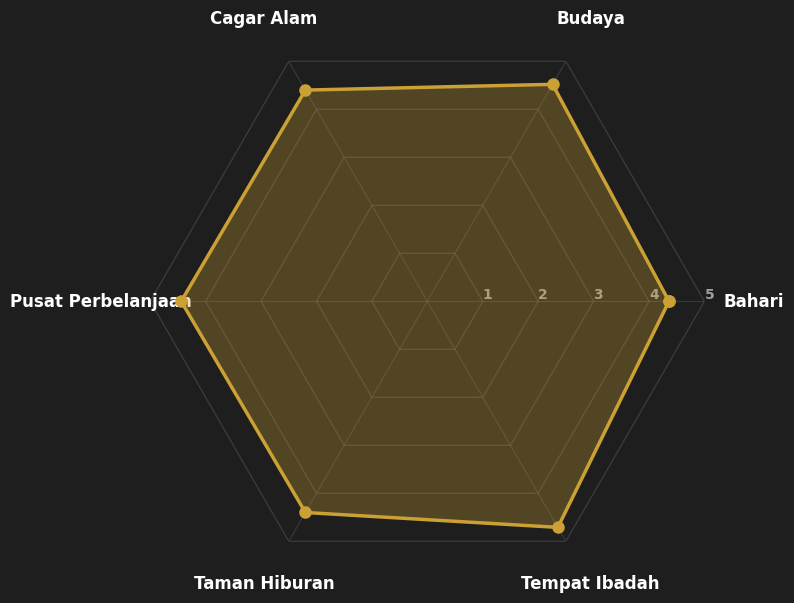

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Data Kategori (Sesuai gambarmu)
kategori = ['Bahari', 'Budaya', 'Cagar Alam', 'Pusat Perbelanjaan', 'Taman Hiburan', 'Tempat Ibadah']
weighted_rating = [4.36, 4.52, 4.40, 4.44, 4.40, 4.71] # Ganti dengan angka aslimu

# Menambahkan elemen pertama ke akhir agar garis grafiknya menutup penuh
kategori = [*kategori, kategori[0]]
weighted_rating = [*weighted_rating, weighted_rating[0]]

# 2. Menghitung sudut untuk setiap sumbu
angles = np.linspace(0, 2 * np.pi, len(kategori) - 1, endpoint=False).tolist()
angles += angles[:1]

# 3. Setup Tema Warna 
warna_background = '#1E1E1E'
warna_aksen = '#CBA135'      
warna_teks = '#FFFFFF'       
warna_grid = '#555555'       
warna_angka = '#A0A0A0' # Abu-abu terang untuk angka rating

# 4. Membuat Figure dan Axis Polar
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.patch.set_facecolor(warna_background)
ax.set_facecolor(warna_background)

# 5. Membuat Jaring Poligon (Segi-Enam)
ax.yaxis.grid(False)
ax.spines['polar'].set_visible(False)

for i in range(1, 6):
    ax.plot(angles, [i]*len(angles), color=warna_grid, linewidth=1, linestyle='solid', alpha=0.5, zorder=1)

ax.xaxis.grid(True, color=warna_grid, linestyle='solid', alpha=0.5, zorder=1)

# 6. Plot Data Spider Chart
ax.plot(angles, weighted_rating, color=warna_aksen, linewidth=2.5, linestyle='solid', marker='o', markersize=8, zorder=3)
ax.fill(angles, weighted_rating, color=warna_aksen, alpha=0.3, zorder=2)

# 7. Kustomisasi Label Kategori (Sumbu X)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(kategori[:-1], color=warna_teks, fontsize=12, weight='bold')
ax.tick_params(axis='x', pad=25) 

# -------------------------------------------------------------
# 8. MENAMPILKAN ANGKA SKALA 1-5
# -------------------------------------------------------------
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['1', '2', '3', '4', '5'], color=warna_angka, fontsize=10, weight='bold')
ax.set_rlabel_position(0) # Menaruh angka di garis lurus sebelah kanan
ax.set_ylim(0, 5) 
# -------------------------------------------------------------

# 9. Simpan Grafik
plt.tight_layout()
plt.savefig('spider_chart_final.png', facecolor=fig.get_facecolor(), edgecolor='none', dpi=300)

print("Grafik final dengan angka berhasil disimpan sebagai 'spider_chart_final.png'")
plt.show()